# BehaveGuard: Multimodal Behavioral Authentication
## From browser telemetry to calibrated 1:1 verification and 1:N identification

**A complete, reproducible Kaggle study:** privacy-preserving data audit → EDA → feature engineering →
leakage-aware temporal validation → classical ML → RBF-SVM tuning → modality ablation → verification
analysis → open-set simulation → BiLSTM + TCN fusion.

> **Research status.** This is a small-cohort development benchmark, not a production biometric claim.
> Most candidates contribute only one real collection session. Chronological windows from the same parent
> session support pipeline validation and within-session separability analysis, but cannot estimate cross-day,
> cross-device, or population-level false-accept rates.

### Questions this notebook answers

1. Which keyboard and mouse behaviors vary across anonymized candidates?
2. Does multimodal fusion outperform either modality alone?
3. How do logistic regression, k-NN, RBF-SVM, Random Forest, and Extra Trees compare?
4. What changes when SVM hyperparameters are selected inside the validation loop?
5. How do identification metrics differ from verification ROC-AUC and equal-error rate (EER)?
6. Can a BiLSTM keyboard encoder and TCN mouse encoder learn complementary sequence representations?
7. How confidently does a closed-set model behave when the true candidate is absent?

## 0. Reproducibility and environment

The notebook uses only packages available in Kaggle's standard Python image. Every randomized component is
seeded. The public dataset contains no names, exact collection timestamps, literal keys, or absolute screen
coordinates.

In [1]:
import json, math, os, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score,
    log_loss, roc_auc_score, roc_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.svm import SVC

import torch
from torch import nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='notebook')
COLORS = ['#0B2545', '#2E74B5', '#40C9A2', '#F4B942', '#D1495B', '#7C77B9']
plt.rcParams.update({
    'figure.figsize': (11, 5.5), 'figure.dpi': 120,
    'axes.titleweight': 'bold', 'axes.titlesize': 14,
    'axes.labelsize': 10, 'legend.frameon': False,
})
print('Device:', DEVICE)
print('pandas:', pd.__version__, '| scikit-learn:', __import__('sklearn').__version__, '| torch:', torch.__version__)

Device: cpu
pandas: 3.0.3 | scikit-learn: 1.9.0 | torch: 2.13.0


## 1. Load the Kaggle dataset

The loader supports Kaggle's `/kaggle/input/...` layout and a local repository checkout. The package is
relational: `session_id` links every table and `subject_id` is an opaque candidate code.

In [2]:
SEARCH_ROOTS = [
    Path('/kaggle/input/behaveguard-multimodal-behavioral-authentication'),
    Path('/kaggle/input/behaveguard-behavioral-authentication'),
    Path('kaggle/behaveguard-dataset'),
    Path('../kaggle/behaveguard-dataset'),
    Path('behaveguard-dataset'),
]
DATA_DIR = next((p for p in SEARCH_ROOTS if (p / 'sessions.csv').exists()), None)
if DATA_DIR is None:
    matches = list(Path('/kaggle/input').glob('**/sessions.csv')) if Path('/kaggle/input').exists() else []
    DATA_DIR = matches[0].parent if matches else None
if DATA_DIR is None:
    raise FileNotFoundError('Attach the BehaveGuard dataset or run the notebook from the repository root.')

FILES = [
    'sessions', 'key_events', 'mouse_passive', 'track_samples', 'track_trials',
    'dot_trials', 'drag_trials', 'session_features', 'window_features',
]
data = {name: pd.read_csv(DATA_DIR / f'{name}.csv') for name in FILES}
sessions = data['sessions']
print('Dataset:', DATA_DIR)
display(pd.DataFrame({
    'table': FILES,
    'rows': [len(data[name]) for name in FILES],
    'columns': [data[name].shape[1] for name in FILES],
    'memory_MB': [data[name].memory_usage(deep=True).sum() / 1e6 for name in FILES],
}).style.format({'rows': '{:,}', 'memory_MB': '{:.2f}'}).hide(axis='index'))

Dataset: ../kaggle/behaveguard-dataset


table,rows,columns,memory_MB
sessions,10,11,0.00
key_events,"6,485",10,2.07
mouse_passive,"30,000",5,4.35
track_samples,"22,404",8,4.94
track_trials,20,15,0.01
dot_trials,250,11,0.05
drag_trials,100,11,0.02
session_features,10,231,0.02
window_features,50,137,0.06


## 2. Integrity, privacy, and coverage audit

We verify referential integrity, expected anonymization, finite timing, and per-candidate coverage before any
modeling. A model trained on malformed event joins can look impressive while learning bookkeeping artifacts.

In [3]:
forbidden_columns = {
    'collected_at', 'press_ts', 'release_ts', 'cursor_x', 'cursor_y',
    'target_x', 'target_y', 'click_x', 'click_y', 'start_x', 'start_y',
    'end_x', 'end_y', 'pressure',
}
session_ids = set(sessions.session_id)
checks = []
for name, frame in data.items():
    if 'session_id' in frame:
        checks.append((name, 'valid session foreign keys', set(frame.session_id).issubset(session_ids)))
    checks.append((name, 'no forbidden raw columns', not bool(forbidden_columns & set(frame.columns))))
    if 'subject_id' in frame:
        checks.append((name, 'opaque candidate labels', frame.subject_id.str.fullmatch(r'candidate_\d+').all()))
checks_df = pd.DataFrame(checks, columns=['table', 'check', 'passed'])
assert checks_df.passed.all(), checks_df[~checks_df.passed]

coverage = sessions.groupby('subject_id').agg(
    real_sessions=('session_id', 'nunique'),
    key_events=('n_keystrokes', 'sum'),
    passive_points=('n_mouse_events', 'sum'),
    dot_trials=('n_dot_targets', 'sum'),
    drag_trials=('n_drags', 'sum'),
    track_trials=('n_track_trials', 'sum'),
).sort_index()
display(checks_df.style.map(lambda v: 'color:#15803d;font-weight:bold' if v is True else '', subset=['passed']).hide(axis='index'))
display(coverage.style.format('{:,.0f}'))

table,check,passed
sessions,valid session foreign keys,True
sessions,no forbidden raw columns,True
sessions,opaque candidate labels,True
key_events,valid session foreign keys,True
key_events,no forbidden raw columns,True
key_events,opaque candidate labels,True
mouse_passive,valid session foreign keys,True
mouse_passive,no forbidden raw columns,True
mouse_passive,opaque candidate labels,True
track_samples,valid session foreign keys,True


,real_sessions,key_events,passive_points,dot_trials,drag_trials,track_trials
subject_id,,,,,,
candidate_01,1,870,"3,000",25,10,2
candidate_02,1,483,"3,000",25,10,2
candidate_03,1,0,"3,000",25,10,2
candidate_04,1,625,"3,000",25,10,2
candidate_05,1,900,"3,000",25,10,2
candidate_06,1,383,"3,000",25,10,2
candidate_07,1,411,"3,000",25,10,2
candidate_08,1,683,"3,000",25,10,2
candidate_09,2,"2,130","6,000",50,20,4


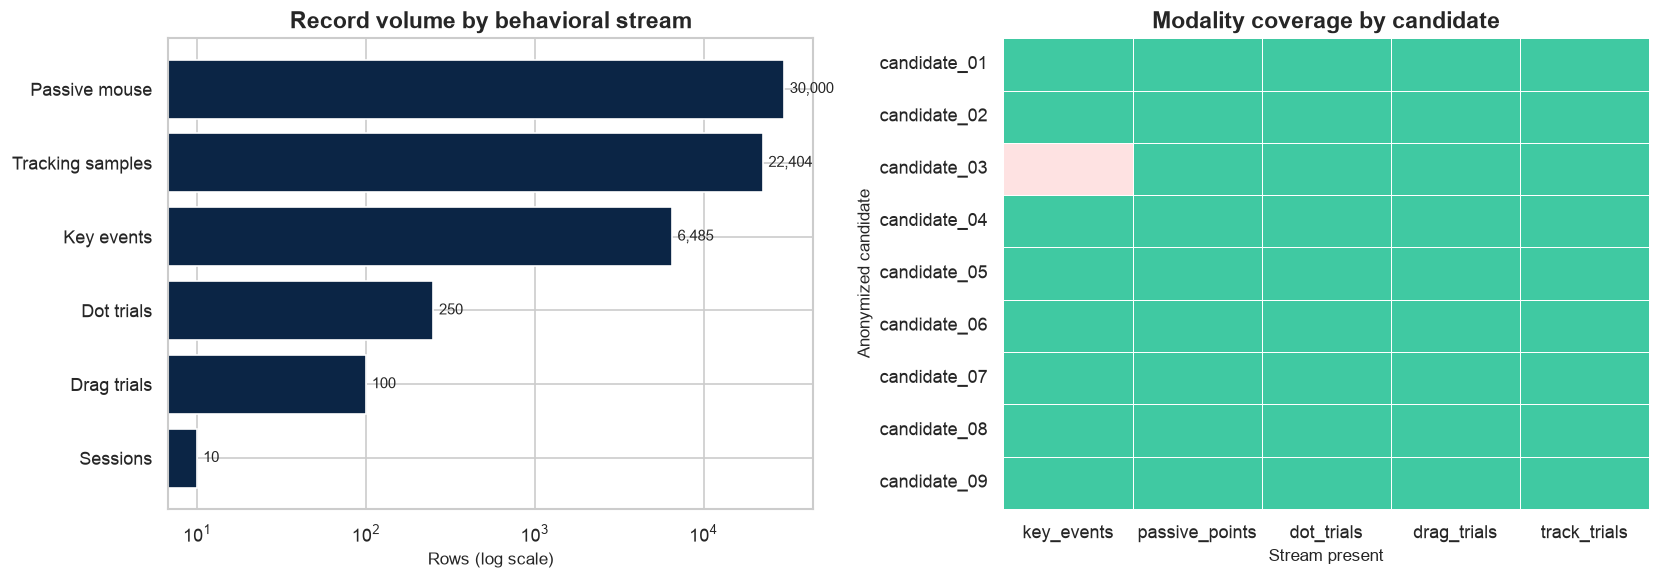

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
volumes = pd.Series({
    'Key events': len(data['key_events']),
    'Passive mouse': len(data['mouse_passive']),
    'Tracking samples': len(data['track_samples']),
    'Dot trials': len(data['dot_trials']),
    'Drag trials': len(data['drag_trials']),
    'Sessions': len(sessions),
}).sort_values()
axes[0].barh(volumes.index, volumes.values, color=COLORS[0])
axes[0].set_xscale('log'); axes[0].set_xlabel('Rows (log scale)')
axes[0].set_title('Record volume by behavioral stream')
for y, value in enumerate(volumes.values):
    axes[0].text(value * 1.08, y, f'{value:,}', va='center', fontsize=9)

sns.heatmap((coverage.drop(columns='real_sessions') > 0).astype(int), cmap=['#FEE2E2', '#40C9A2'],
            cbar=False, linewidths=.5, ax=axes[1])
axes[1].set_title('Modality coverage by candidate')
axes[1].set_xlabel('Stream present'); axes[1].set_ylabel('Anonymized candidate')
plt.tight_layout(); plt.show()

**Coverage interpretation.** Mouse data is complete across the roster. One candidate has no usable keyboard
release stream, so keyboard-only models must use imputation and the benchmark must report modality failures.
Candidate/session counts are deliberately shown because error rates without trial counts are misleading.

## 3. Exploratory data analysis
### 3.1 Keyboard rhythm and typing speed

`typing_wpm` uses the standard five-character word equivalent over the active keyboard span. It is a behavioral
descriptor, not a productivity score. Dwell is press-to-release time; inter-key interval (IKI) is the time between
consecutive presses; flight time is the next press minus the previous release and may be negative when keys overlap.

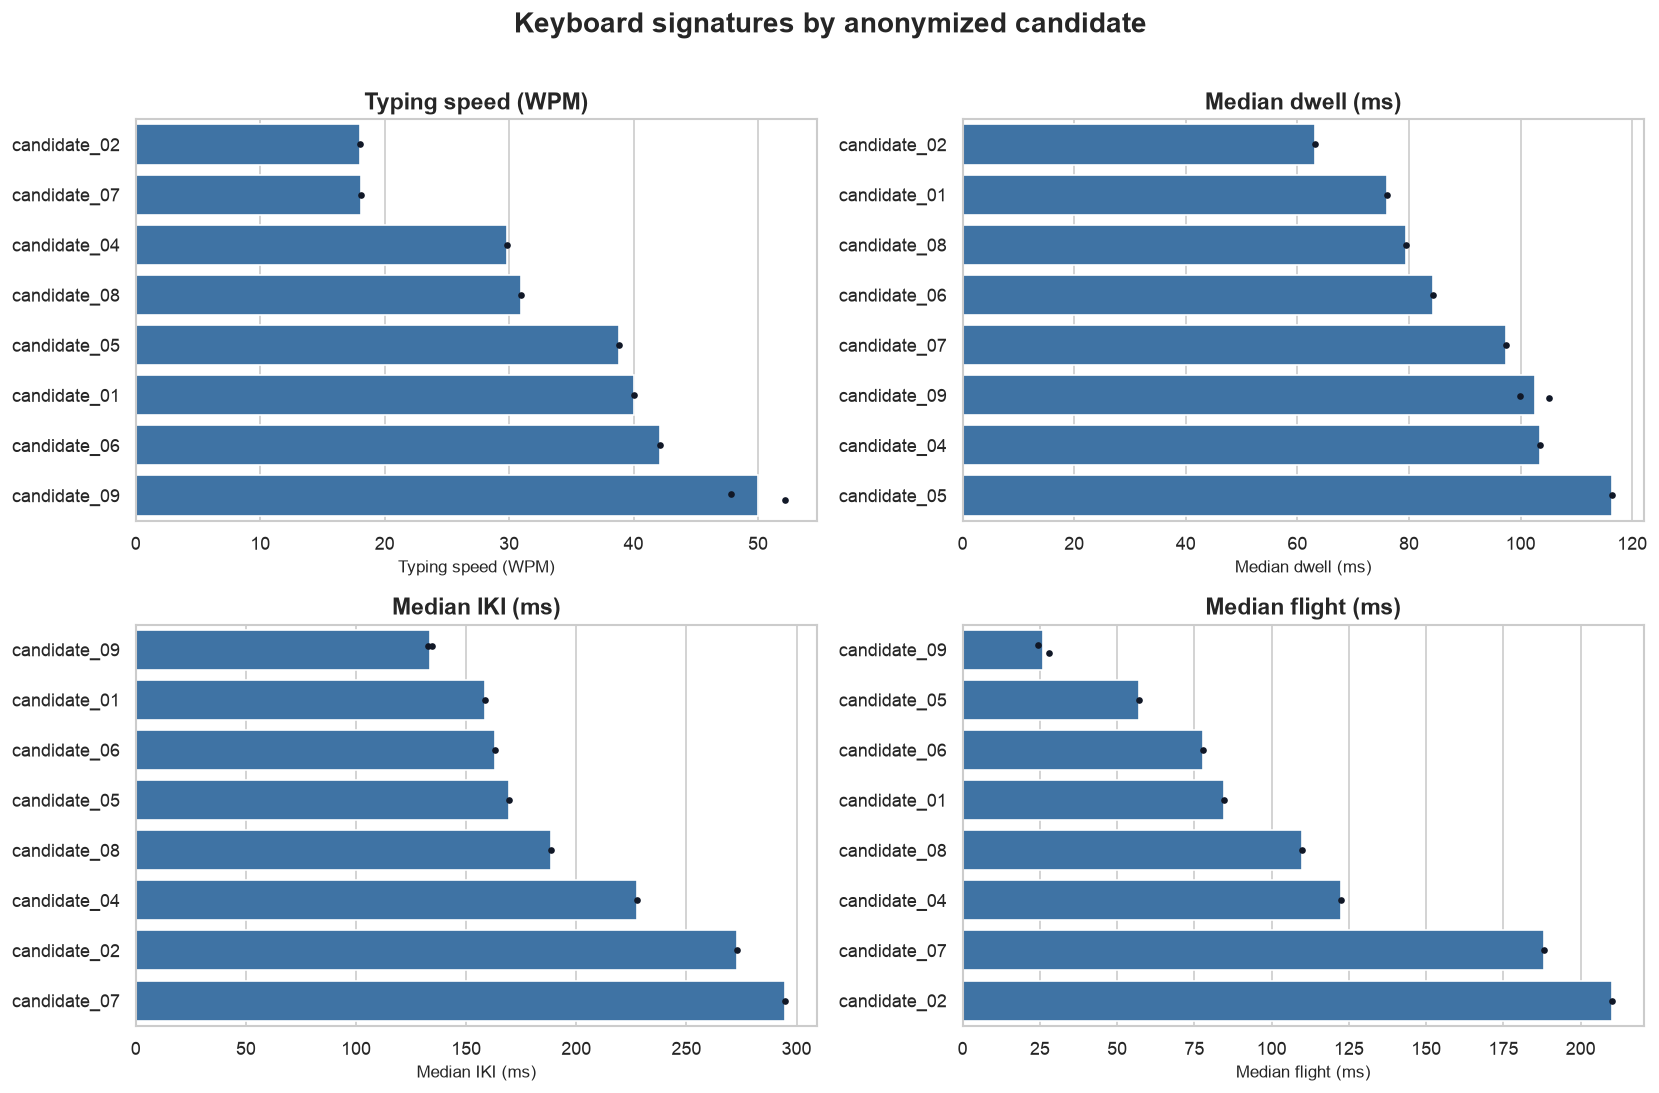

In [5]:
sf = data['session_features'].copy()
keyboard_cols = ['typing_wpm', 'key_dwell_ms_p50', 'key_iki_ms_p50', 'key_flight_ms_p50']
keyboard_long = sf.melt(id_vars=['subject_id', 'session_id'], value_vars=keyboard_cols,
                        var_name='metric', value_name='value').dropna()
pretty = {
    'typing_wpm': 'Typing speed (WPM)', 'key_dwell_ms_p50': 'Median dwell (ms)',
    'key_iki_ms_p50': 'Median IKI (ms)', 'key_flight_ms_p50': 'Median flight (ms)',
}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (metric, label) in zip(axes.flat, pretty.items()):
    subset = keyboard_long[keyboard_long.metric == metric]
    order = subset.groupby('subject_id').value.median().sort_values().index
    sns.barplot(data=subset, x='value', y='subject_id', order=order, color=COLORS[1], errorbar=None, ax=ax)
    sns.stripplot(data=subset, x='value', y='subject_id', order=order, color='#111827', size=4, ax=ax)
    ax.set_title(label); ax.set_xlabel(label); ax.set_ylabel('')
fig.suptitle('Keyboard signatures by anonymized candidate', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 3.2 Passive and goal-directed mouse behavior

Passive motion captures habitual speed, pauses, and turning. Goal-directed tasks add endpoint precision,
sub-movement corrections, drag timing, pursuit lag, and tracking error—signals that are difficult to summarize
with a single average.

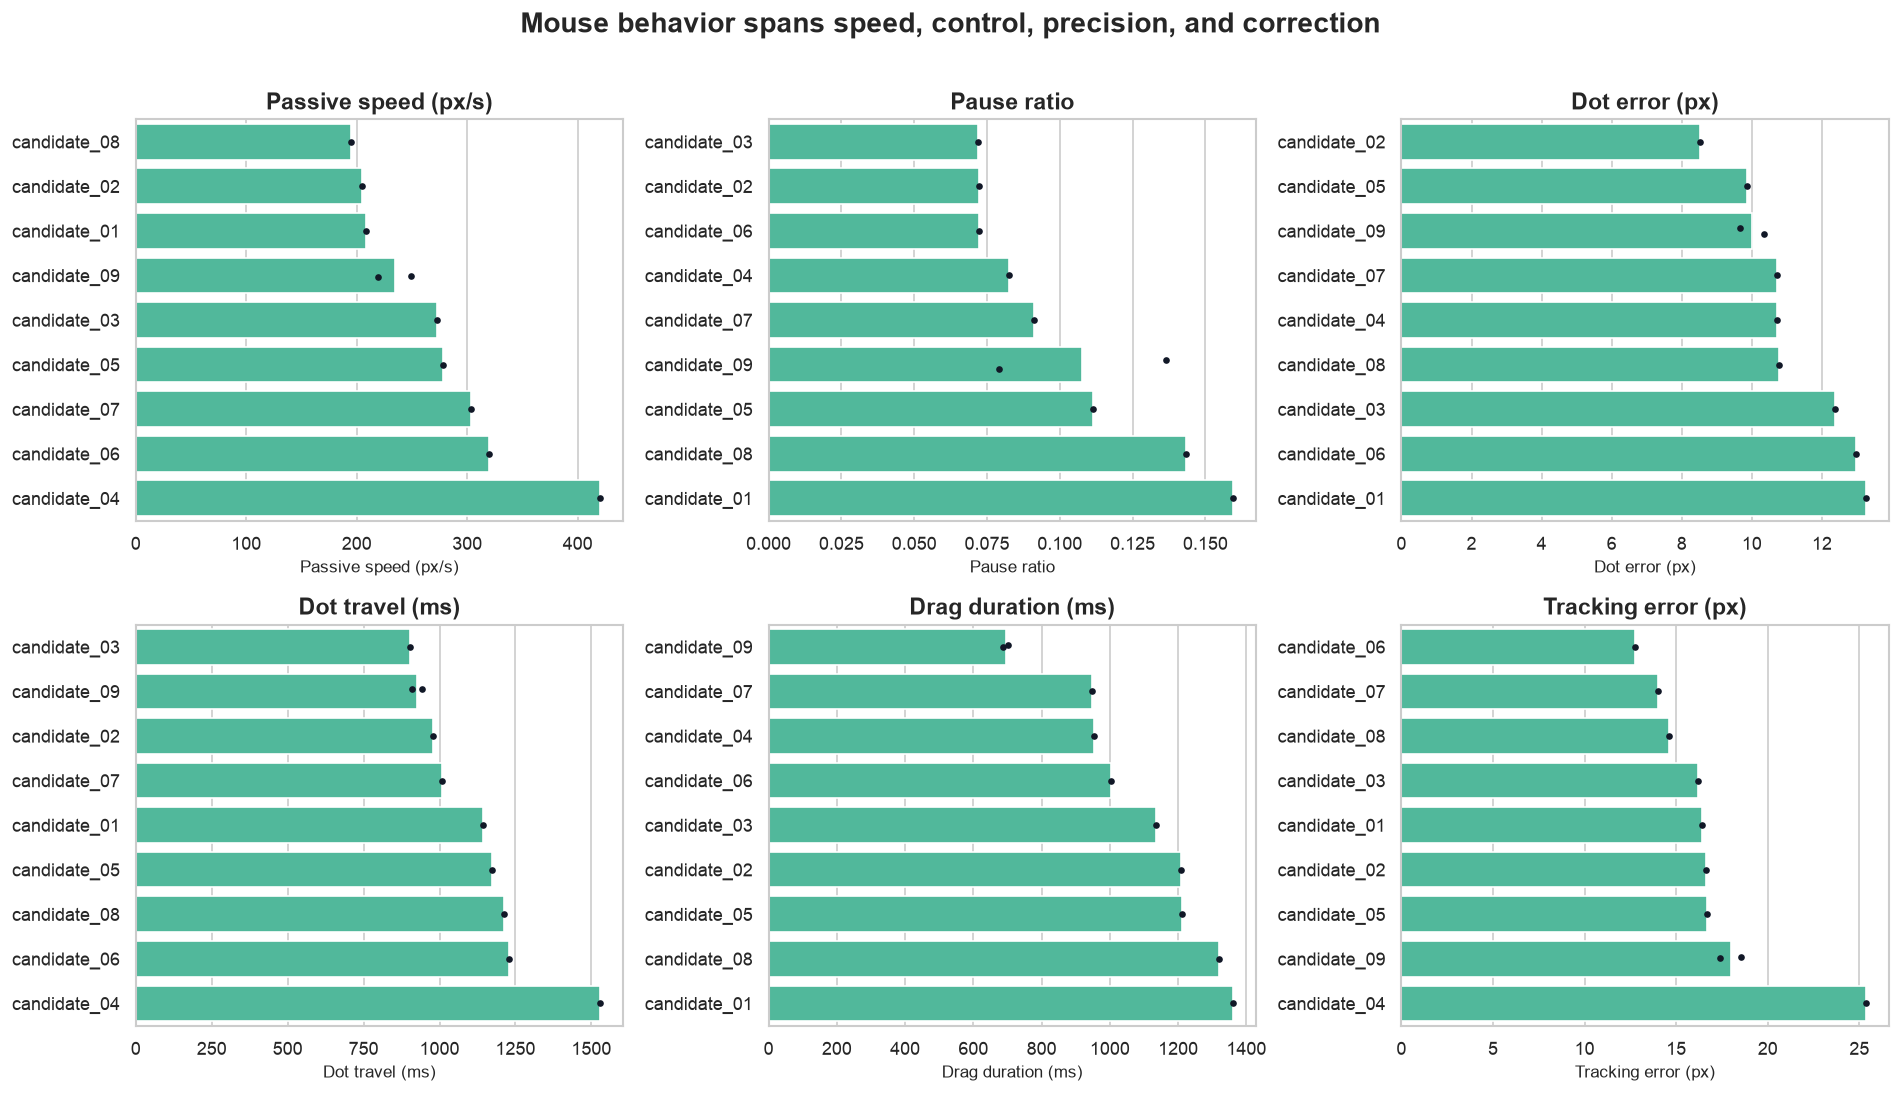

In [6]:
mouse_metrics = pd.DataFrame({
    'subject_id': sf.subject_id,
    'Passive speed (px/s)': sf.mouse_speed_p50,
    'Pause ratio': sf.mouse_pause_ratio,
    'Dot error (px)': sf.dot_error_px_mean,
    'Dot travel (ms)': sf.dot_travel_time_ms_mean,
    'Drag duration (ms)': sf.drag_duration_ms_mean,
    'Tracking error (px)': sf.track_random_walk_sample_error_px_mean,
})
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, metric in zip(axes.flat, mouse_metrics.columns[1:]):
    order = mouse_metrics.groupby('subject_id')[metric].median().sort_values().index
    sns.barplot(data=mouse_metrics, x=metric, y='subject_id', order=order,
                color=COLORS[2], errorbar=None, ax=ax)
    sns.stripplot(data=mouse_metrics, x=metric, y='subject_id', order=order,
                  color='#111827', size=4, ax=ax)
    ax.set_title(metric); ax.set_ylabel('')
fig.suptitle('Mouse behavior spans speed, control, precision, and correction', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

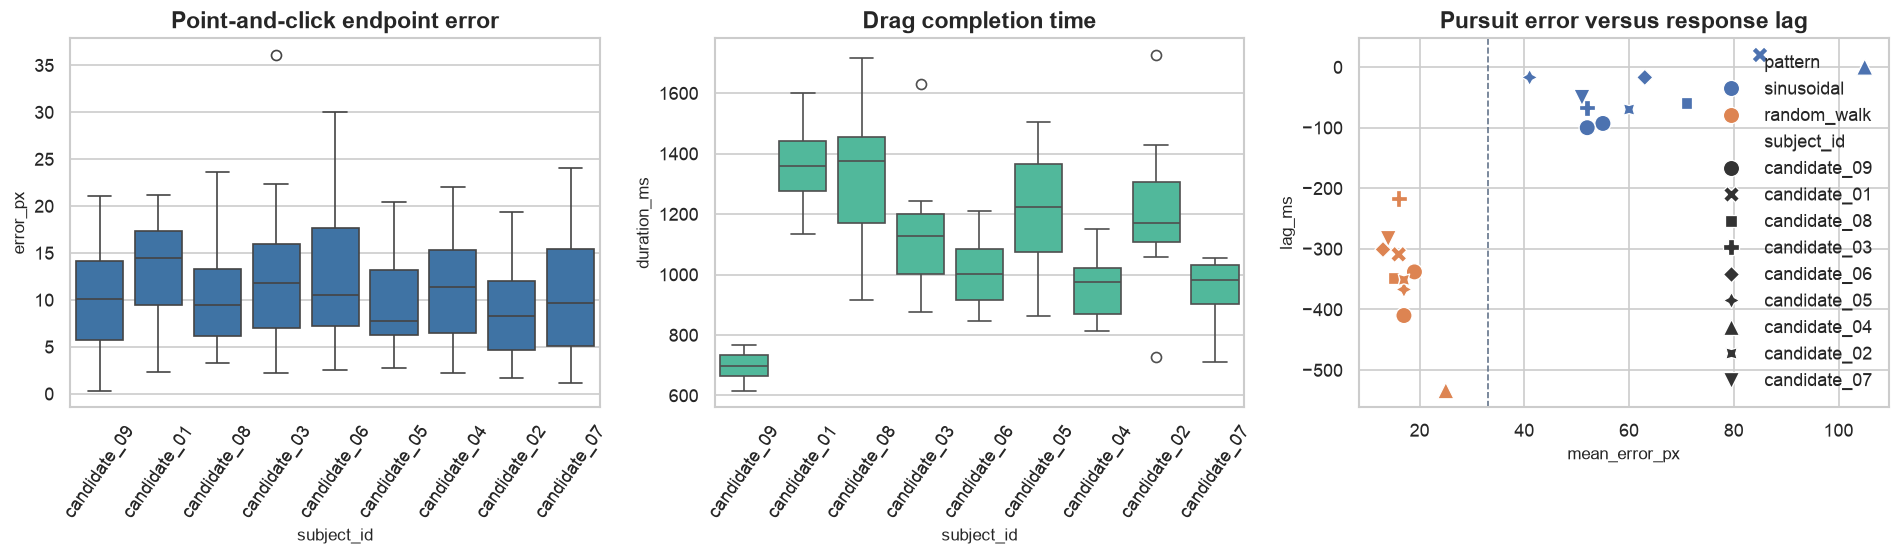

In [7]:
trials = data['track_trials'].copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.boxplot(data=data['dot_trials'], x='subject_id', y='error_px', color=COLORS[1], ax=axes[0])
axes[0].tick_params(axis='x', rotation=55); axes[0].set_title('Point-and-click endpoint error')
sns.boxplot(data=data['drag_trials'], x='subject_id', y='duration_ms', color=COLORS[2], ax=axes[1])
axes[1].tick_params(axis='x', rotation=55); axes[1].set_title('Drag completion time')
sns.scatterplot(data=trials, x='mean_error_px', y='lag_ms', hue='pattern', style='subject_id', s=95, ax=axes[2])
axes[2].axvline(trials.mean_error_px.median(), color='#64748B', ls='--', lw=1)
axes[2].set_title('Pursuit error versus response lag')
plt.tight_layout(); plt.show()

### 3.3 Multimodal fingerprints and low-dimensional structure

The heatmap robustly standardizes selected session features. It is descriptive—not evidence that each candidate
will remain equally separated on another day or device.

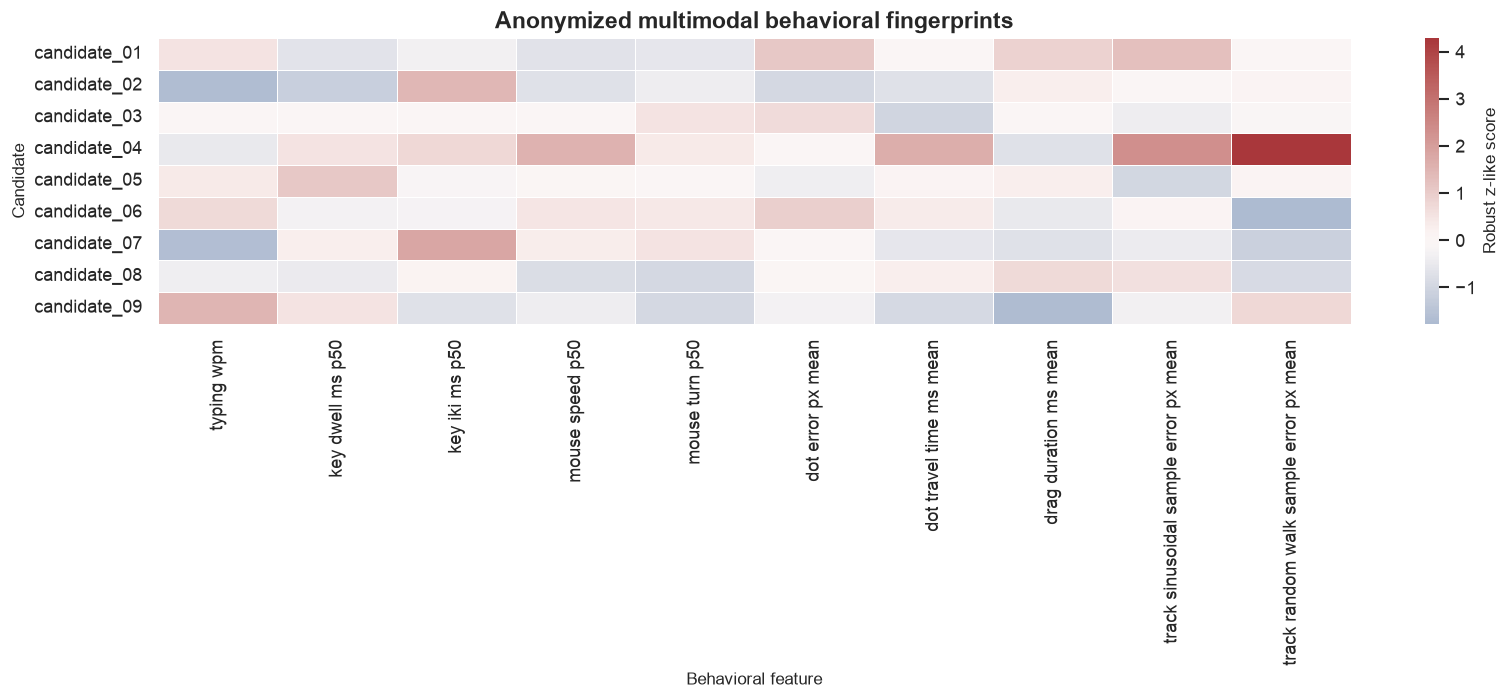

In [8]:
fingerprint_features = [
    'typing_wpm', 'key_dwell_ms_p50', 'key_iki_ms_p50', 'mouse_speed_p50',
    'mouse_turn_p50', 'dot_error_px_mean', 'dot_travel_time_ms_mean',
    'drag_duration_ms_mean', 'track_sinusoidal_sample_error_px_mean',
    'track_random_walk_sample_error_px_mean',
]
fingerprints = sf.groupby('subject_id')[fingerprint_features].median()
standardized = pd.DataFrame(
    RobustScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(fingerprints)),
    index=fingerprints.index,
    columns=[c.replace('_', ' ') for c in fingerprint_features],
)
plt.figure(figsize=(14, 6))
sns.heatmap(standardized, cmap='vlag', center=0, linewidths=.4, cbar_kws={'label': 'Robust z-like score'})
plt.title('Anonymized multimodal behavioral fingerprints')
plt.xlabel('Behavioral feature'); plt.ylabel('Candidate')
plt.tight_layout(); plt.show()

## 4. Modeling table and leakage controls

Each real session is divided into five **chronological, non-overlapping** pseudo-samples. `window_index` defines
five outer folds: fold 1 tests the first window from every parent session, and so on. Preprocessing is fitted inside
each fold. Hyperparameter tuning is nested inside the outer loop.

This design avoids overlapping windows and direct row leakage, but train and test windows still come from the same
real sessions. The resulting metrics answer *“can the pipeline distinguish behavior within this collection?”*, not
*“will it authenticate a person next week?”*

In [9]:
wf = data['window_features'].copy()
ID_COLUMNS = ['sample_id', 'session_id', 'subject_id', 'window_index']
feature_names = [c for c in wf.columns if c not in ID_COLUMNS]
missing = wf[feature_names].isna().mean()
constant = wf[feature_names].nunique(dropna=True) <= 1
feature_names = [c for c in feature_names if missing[c] <= .35 and not constant[c]]
X = wf[feature_names].astype(float).to_numpy()
y = wf.subject_id.to_numpy()
folds = wf.window_index.to_numpy()
classes = np.array(sorted(np.unique(y)))
class_to_index = {label: i for i, label in enumerate(classes)}

modality = {
    'Keyboard': [i for i, c in enumerate(feature_names) if c.startswith('key_') or c == 'typing_wpm'],
    'Passive mouse': [i for i, c in enumerate(feature_names) if c.startswith('mouse_')],
    'Active mouse': [i for i, c in enumerate(feature_names) if c.startswith(('dot_', 'drag_', 'track_'))],
}
print(f'{len(wf)} windows | {len(classes)} candidates | {len(feature_names)} usable features')
print({name: len(indexes) for name, indexes in modality.items()})
display(pd.DataFrame({'feature': feature_names, 'missing_rate': [missing[c] for c in feature_names]})
        .sort_values('missing_rate', ascending=False).head(12).style.format({'missing_rate': '{:.1%}'}).hide(axis='index'))

50 windows | 9 candidates | 133 usable features
{'Keyboard': 23, 'Passive mouse': 19, 'Active mouse': 91}


feature,missing_rate
key_dwell_ms_mean,10.0%
key_flight_ms_mean,10.0%
key_dwell_ms_std,10.0%
typing_wpm,10.0%
key_special_rate,10.0%
key_space_rate,10.0%
key_shift_rate,10.0%
key_backspace_rate,10.0%
key_flight_ms_p90,10.0%
key_flight_ms_p50,10.0%


In [10]:
def score_matrix(estimator, X_test, global_classes):
    if hasattr(estimator, 'predict_proba'):
        raw = np.asarray(estimator.predict_proba(X_test), dtype=float)
    else:
        raw = np.asarray(estimator.decision_function(X_test), dtype=float)
        if raw.ndim == 1:
            raw = np.column_stack([-raw, raw])
    scores = np.full((len(X_test), len(global_classes)), np.nan)
    for local, label in enumerate(estimator.classes_):
        scores[:, np.where(global_classes == label)[0][0]] = raw[:, local]
    floor = np.nanmin(scores[np.isfinite(scores)]) - 1 if np.isfinite(scores).any() else -1
    return np.nan_to_num(scores, nan=floor)

def verification_metrics(labels, scores, global_classes):
    target = np.array([np.where(global_classes == label)[0][0] for label in labels])
    genuine = np.eye(len(global_classes), dtype=int)[target].ravel()
    flat_scores = scores.ravel()
    auc = roc_auc_score(genuine, flat_scores)
    fpr, tpr, thresholds = roc_curve(genuine, flat_scores)
    fnr = 1 - tpr
    idx = int(np.argmin(np.abs(fpr - fnr)))
    return {
        'verification_auc': auc,
        'eer': (fpr[idx] + fnr[idx]) / 2,
        'eer_threshold': thresholds[idx],
        'fpr': fpr, 'tpr': tpr,
    }

def evaluate_temporal_cv(estimator, X_data=X, labels=y, fold_ids=folds):
    predictions = np.empty(len(labels), dtype=object)
    scores = np.zeros((len(labels), len(classes)))
    for fold in sorted(np.unique(fold_ids)):
        train, test = fold_ids != fold, fold_ids == fold
        model = clone(estimator).fit(X_data[train], labels[train])
        predictions[test] = model.predict(X_data[test])
        scores[test] = score_matrix(model, X_data[test], classes)
    targets = np.array([class_to_index[label] for label in labels])
    top3 = np.argsort(scores, axis=1)[:, -min(3, len(classes)):]
    verification = verification_metrics(labels, scores, classes)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'balanced_accuracy': balanced_accuracy_score(labels, predictions),
        'macro_f1': f1_score(labels, predictions, average='macro'),
        'top3_accuracy': np.mean([target in choices for target, choices in zip(targets, top3)]),
        **verification,
        'predictions': predictions,
        'scores': scores,
        'confusion': confusion_matrix(labels, predictions, labels=classes),
    }

## 5. Classical model benchmark

Linear, neighborhood, kernel, and tree ensembles provide complementary inductive biases. Every linear/distance
model receives median imputation and robust scaling inside its fold; tree models receive median imputation.

In [11]:
models = {
    'Logistic regression': make_pipeline(
        SimpleImputer(strategy='median'), RobustScaler(quantile_range=(10, 90)),
        LogisticRegression(C=1, max_iter=4000, class_weight='balanced', random_state=SEED),
    ),
    '3-NN': make_pipeline(
        SimpleImputer(strategy='median'), RobustScaler(quantile_range=(10, 90)),
        KNeighborsClassifier(n_neighbors=3, weights='distance'),
    ),
    'RBF-SVM (default)': make_pipeline(
        SimpleImputer(strategy='median'), RobustScaler(quantile_range=(10, 90)),
        SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced', decision_function_shape='ovr'),
    ),
    'Random Forest': make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(n_estimators=500, min_samples_leaf=2, max_features='sqrt',
                               class_weight='balanced', random_state=SEED, n_jobs=-1),
    ),
    'Extra Trees': make_pipeline(
        SimpleImputer(strategy='median'),
        ExtraTreesClassifier(n_estimators=500, min_samples_leaf=2, max_features='sqrt',
                             class_weight='balanced', random_state=SEED, n_jobs=-1),
    ),
}
classical = {name: evaluate_temporal_cv(model) for name, model in models.items()}
classical_table = pd.DataFrame({name: {
    'Balanced accuracy': result['balanced_accuracy'], 'Macro-F1': result['macro_f1'],
    'Top-1': result['accuracy'], 'Top-3': result['top3_accuracy'],
    'Verification ROC-AUC': result['verification_auc'], 'EER': result['eer'],
} for name, result in classical.items()}).T.sort_values('Balanced accuracy', ascending=False)
display(classical_table.style.format('{:.1%}').background_gradient(cmap='YlGn', subset=['Balanced accuracy', 'Macro-F1', 'Top-1', 'Top-3', 'Verification ROC-AUC'])
        .background_gradient(cmap='YlOrRd_r', subset=['EER']))

,Balanced accuracy,Macro-F1,Top-1,Top-3,Verification ROC-AUC,EER
Extra Trees,95.6%,95.6%,96.0%,100.0%,99.7%,2.3%
Random Forest,93.3%,93.5%,94.0%,100.0%,99.8%,1.5%
3-NN,68.9%,65.2%,70.0%,86.0%,90.5%,12.6%
Logistic regression,65.6%,64.5%,68.0%,96.0%,95.3%,9.7%
RBF-SVM (default),65.6%,66.1%,66.0%,86.0%,91.5%,20.1%


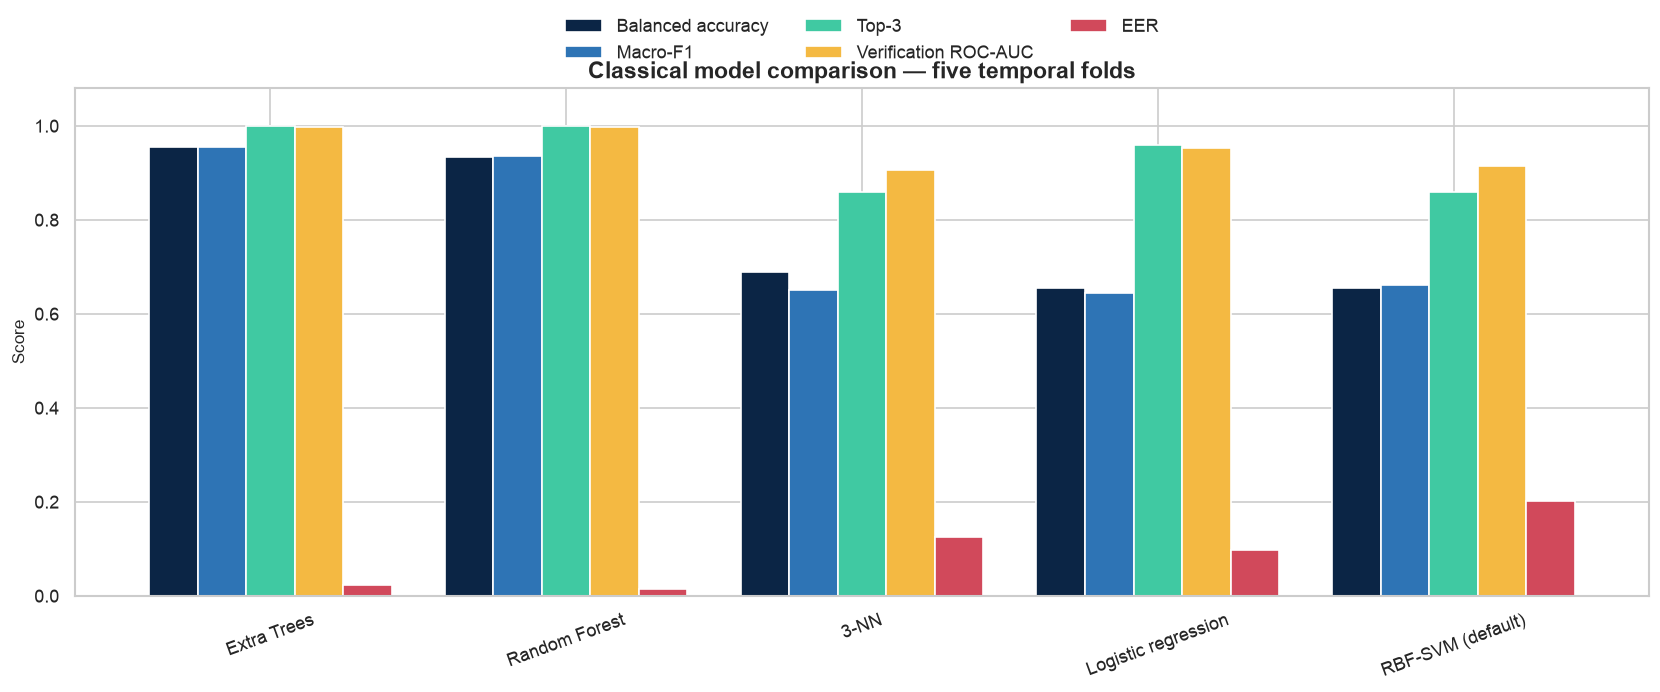

In [12]:
plot_metrics = classical_table[['Balanced accuracy', 'Macro-F1', 'Top-3', 'Verification ROC-AUC', 'EER']]
ax = plot_metrics.plot(kind='bar', figsize=(14, 6), color=COLORS[:5], width=.82)
ax.set_ylim(0, 1.08); ax.set_ylabel('Score'); ax.set_xlabel('')
ax.set_title('Classical model comparison — five temporal folds')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(.5, 1.17))
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## 6. Nested RBF-SVM hyperparameter tuning

Selecting `C` and `gamma` on the same folds used for reporting is optimistic. For each outer test window, this
notebook evaluates the grid only on the remaining temporal windows, selects the best inner balanced accuracy,
refits on the full outer-training set, and then scores the untouched outer fold.

In [13]:
C_GRID = [0.1, 1, 10, 50]
GAMMA_GRID = ['scale', 0.001, 0.01, 0.1]

def svm_pipeline(C, gamma):
    return make_pipeline(
        SimpleImputer(strategy='median'), RobustScaler(quantile_range=(10, 90)),
        SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', decision_function_shape='ovr'),
    )

tuned_predictions = np.empty(len(y), dtype=object)
tuned_scores = np.zeros((len(y), len(classes)))
selections, inner_records = [], []
for outer in sorted(np.unique(folds)):
    outer_train, outer_test = folds != outer, folds == outer
    available_inner = sorted(np.unique(folds[outer_train]))
    candidates = []
    for C in C_GRID:
        for gamma in GAMMA_GRID:
            inner_scores = []
            for inner in available_inner:
                train = outer_train & (folds != inner)
                valid = outer_train & (folds == inner)
                model = svm_pipeline(C, gamma).fit(X[train], y[train])
                inner_scores.append(balanced_accuracy_score(y[valid], model.predict(X[valid])))
            mean_score = float(np.mean(inner_scores))
            candidates.append((mean_score, C, gamma))
            inner_records.append({'outer_fold': outer, 'C': C, 'gamma': str(gamma), 'balanced_accuracy': mean_score})
    _, best_C, best_gamma = max(candidates, key=lambda row: (row[0], -float(row[1])))
    selections.append({'outer_fold': outer, 'C': best_C, 'gamma': str(best_gamma)})
    model = svm_pipeline(best_C, best_gamma).fit(X[outer_train], y[outer_train])
    tuned_predictions[outer_test] = model.predict(X[outer_test])
    tuned_scores[outer_test] = score_matrix(model, X[outer_test], classes)

tuned_verification = verification_metrics(y, tuned_scores, classes)
tuned_result = {
    'accuracy': accuracy_score(y, tuned_predictions),
    'balanced_accuracy': balanced_accuracy_score(y, tuned_predictions),
    'macro_f1': f1_score(y, tuned_predictions, average='macro'),
    'top3_accuracy': np.mean([
        class_to_index[label] in choices
        for label, choices in zip(y, np.argsort(tuned_scores, axis=1)[:, -3:])
    ]),
    **tuned_verification,
    'predictions': tuned_predictions,
    'scores': tuned_scores,
    'confusion': confusion_matrix(y, tuned_predictions, labels=classes),
}
display(pd.DataFrame(selections).style.hide(axis='index'))
print('Nested tuned SVM balanced accuracy:', f"{tuned_result['balanced_accuracy']:.1%}")

outer_fold,C,gamma
1,10.000000,0.001
2,0.100000,scale
3,10.000000,0.01
4,50.000000,0.001
5,10.000000,0.01


Nested tuned SVM balanced accuracy: 67.8%


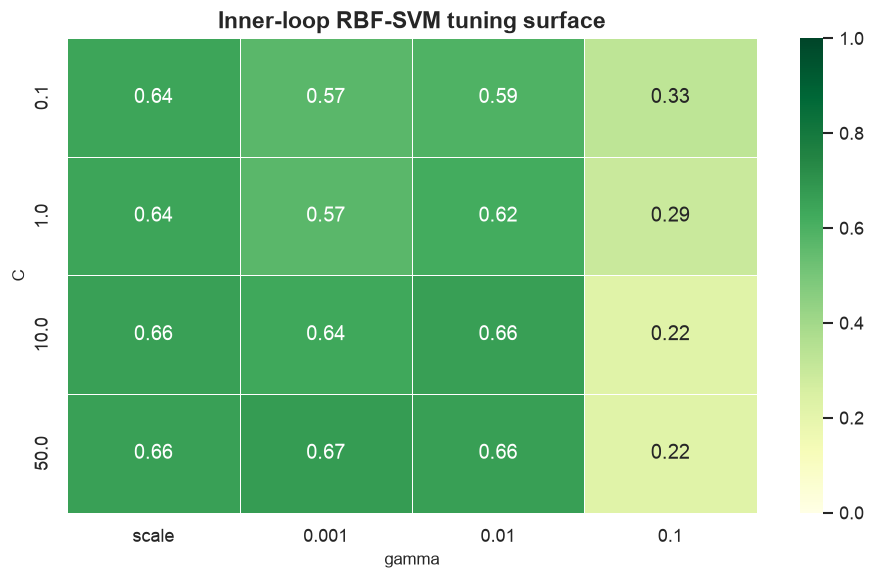

In [14]:
inner_df = pd.DataFrame(inner_records)
heat = inner_df.groupby(['C', 'gamma']).balanced_accuracy.mean().unstack()
heat = heat.reindex(index=C_GRID, columns=[str(g) for g in GAMMA_GRID])
plt.figure(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlGn', vmin=0, vmax=1, linewidths=.5)
plt.title('Inner-loop RBF-SVM tuning surface')
plt.xlabel('gamma'); plt.ylabel('C')
plt.tight_layout(); plt.show()

## 7. Identification errors and verification operating characteristics

Closed-set **identification** asks which enrolled candidate is closest. **Verification** asks whether a claimed
identity should be accepted. ROC-AUC measures ranking over genuine/impostor pairs; EER is the comparison point
where false-accept and false-reject rates are approximately equal. Neither is a deployment threshold by itself.

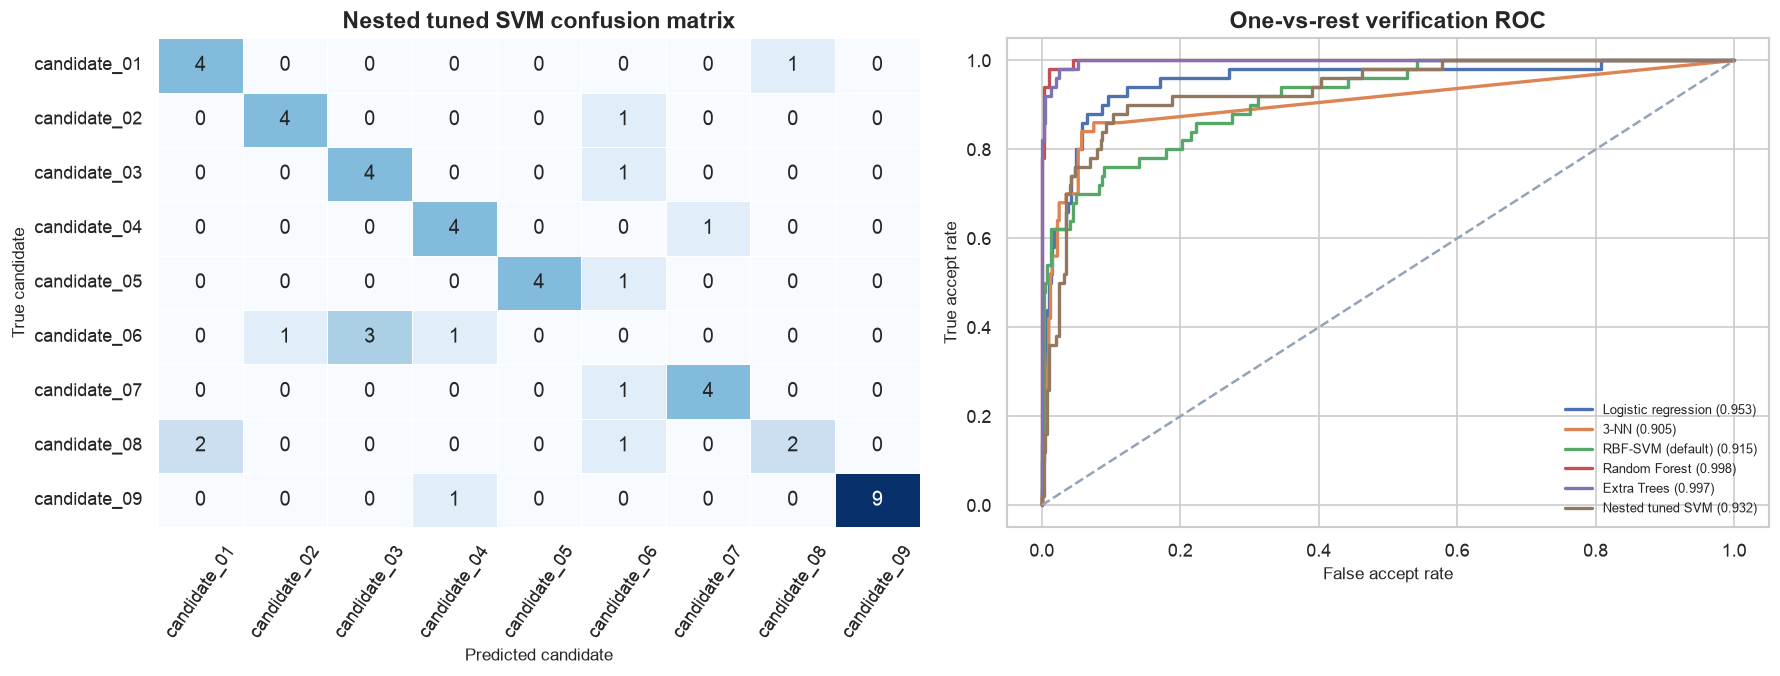

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
sns.heatmap(tuned_result['confusion'], annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes, linewidths=.5, ax=axes[0])
axes[0].set_title('Nested tuned SVM confusion matrix')
axes[0].set_xlabel('Predicted candidate'); axes[0].set_ylabel('True candidate')
axes[0].tick_params(axis='x', rotation=55)

for name, result in {**classical, 'Nested tuned SVM': tuned_result}.items():
    axes[1].plot(result['fpr'], result['tpr'], lw=2, label=f"{name} ({result['verification_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], '--', color='#94A3B8')
axes[1].set(xlabel='False accept rate', ylabel='True accept rate', title='One-vs-rest verification ROC')
axes[1].legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

Observed at comparison EER threshold (7.048): FAR=12.25%, FRR=12.00%
Pair counts: 50 genuine, 400 impostor


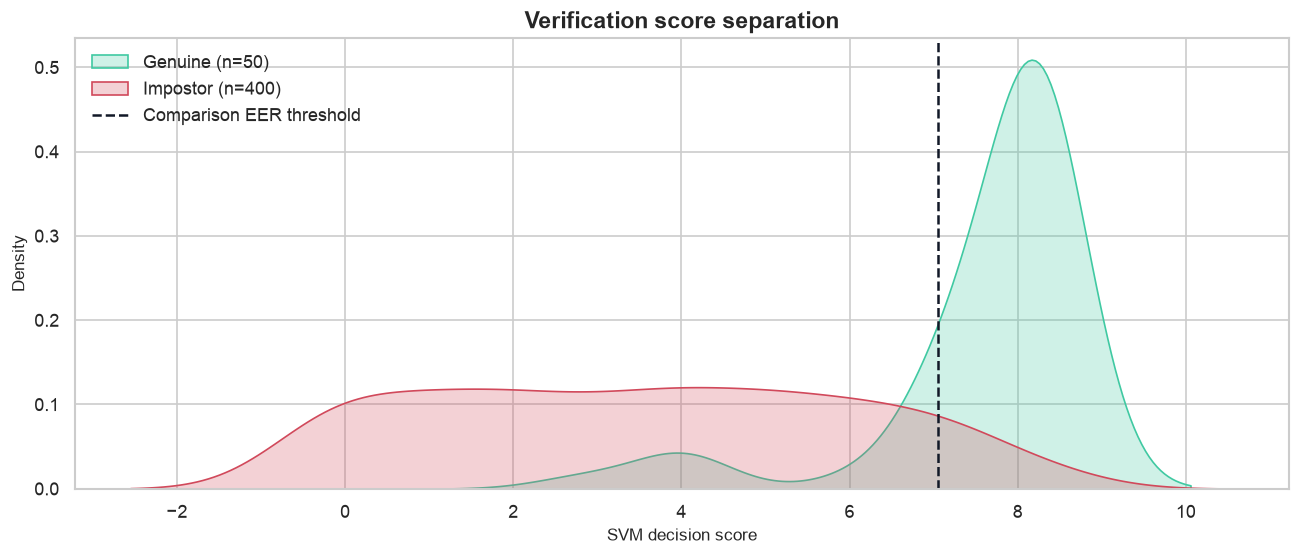

In [16]:
genuine_mask = np.eye(len(classes), dtype=bool)[[class_to_index[label] for label in y]]
genuine_scores = tuned_scores[genuine_mask]
impostor_scores = tuned_scores[~genuine_mask]
threshold = tuned_result['eer_threshold']
observed_far = np.mean(impostor_scores >= threshold)
observed_frr = np.mean(genuine_scores < threshold)
print(f'Observed at comparison EER threshold ({threshold:.3f}): FAR={observed_far:.2%}, FRR={observed_frr:.2%}')
print(f'Pair counts: {len(genuine_scores)} genuine, {len(impostor_scores)} impostor')

plt.figure(figsize=(11, 4.8))
sns.kdeplot(genuine_scores, fill=True, color=COLORS[2], label=f'Genuine (n={len(genuine_scores)})')
sns.kdeplot(impostor_scores, fill=True, color=COLORS[4], label=f'Impostor (n={len(impostor_scores)})')
plt.axvline(threshold, color='#111827', ls='--', label='Comparison EER threshold')
plt.title('Verification score separation')
plt.xlabel('SVM decision score'); plt.legend(); plt.tight_layout(); plt.show()

## 8. Modality ablation

The same tuned-SVM structure is evaluated with keyboard, passive mouse, active mouse, all mouse, and full fusion
features. This tests complementarity; it does not prove causal contribution because the cohort is small and one
keyboard stream is missing.

,Balanced accuracy,Macro-F1,ROC-AUC,EER
Keyboard,45.6%,42.6%,77.0%,32.2%
Passive mouse,25.6%,23.4%,67.8%,34.2%
Active mouse,51.1%,47.5%,86.8%,20.6%
All mouse,58.9%,54.5%,89.6%,18.4%
Full fusion,67.8%,64.0%,94.1%,14.1%


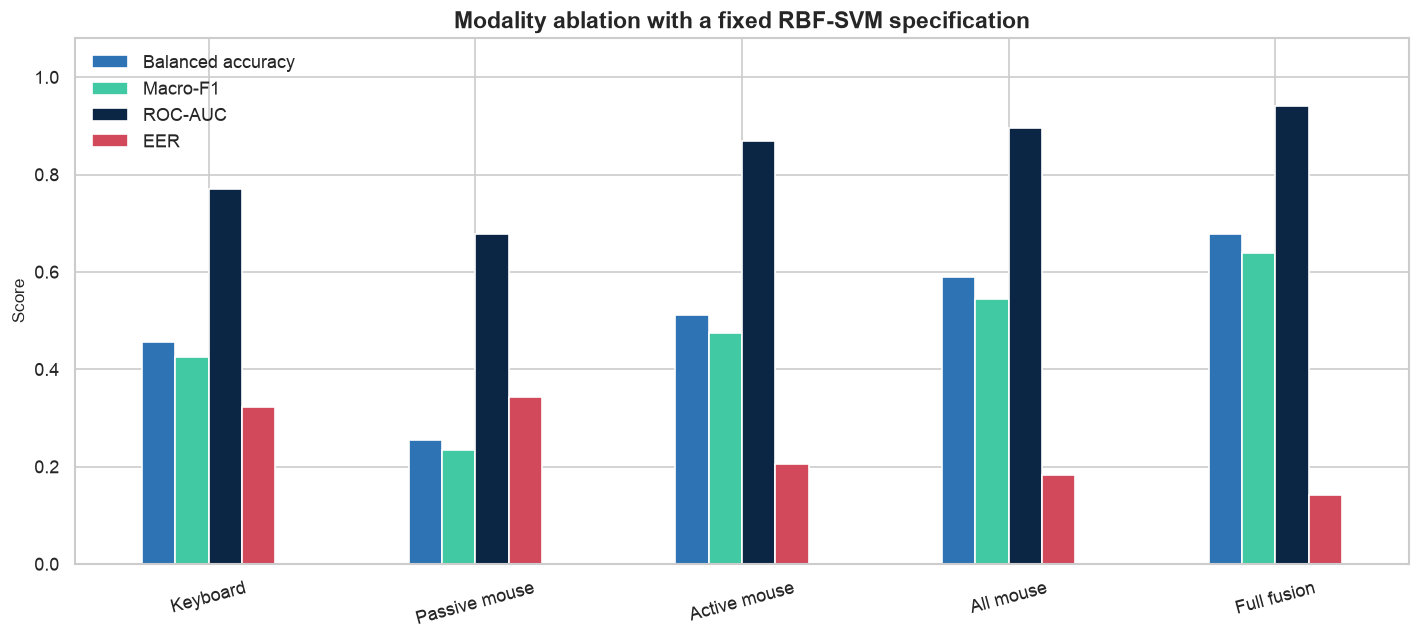

In [17]:
ablation_indices = {
    'Keyboard': modality['Keyboard'],
    'Passive mouse': modality['Passive mouse'],
    'Active mouse': modality['Active mouse'],
    'All mouse': modality['Passive mouse'] + modality['Active mouse'],
    'Full fusion': list(range(len(feature_names))),
}
# Use the modal nested selection as a fixed specification for a fair ablation.
selected = pd.DataFrame(selections)
modal_C = float(selected.C.mode().iloc[0])
modal_gamma_text = selected.gamma.mode().iloc[0]
modal_gamma = 'scale' if modal_gamma_text == 'scale' else float(modal_gamma_text)
ablations = {}
for name, indexes in ablation_indices.items():
    ablations[name] = evaluate_temporal_cv(svm_pipeline(modal_C, modal_gamma), X[:, indexes], y, folds)
ablation_table = pd.DataFrame({name: {
    'Balanced accuracy': result['balanced_accuracy'], 'Macro-F1': result['macro_f1'],
    'ROC-AUC': result['verification_auc'], 'EER': result['eer'],
} for name, result in ablations.items()}).T
display(ablation_table.style.format('{:.1%}').background_gradient(cmap='YlGn', subset=['Balanced accuracy', 'Macro-F1', 'ROC-AUC'])
        .background_gradient(cmap='YlOrRd_r', subset=['EER']))

ax = ablation_table.plot(kind='bar', figsize=(12, 5.5), color=[COLORS[1], COLORS[2], COLORS[0], COLORS[4]])
ax.set_ylim(0, 1.08); ax.set_ylabel('Score'); ax.set_xlabel('')
ax.set_title('Modality ablation with a fixed RBF-SVM specification')
ax.tick_params(axis='x', rotation=15); plt.tight_layout(); plt.show()

## 9. Explainability: stable signals, not identity causes

Permutation importance measures validation-score degradation when a feature is shuffled. It identifies useful
predictors in this dataset; it does **not** show why a person behaves a certain way or whether a feature is stable
across context changes.

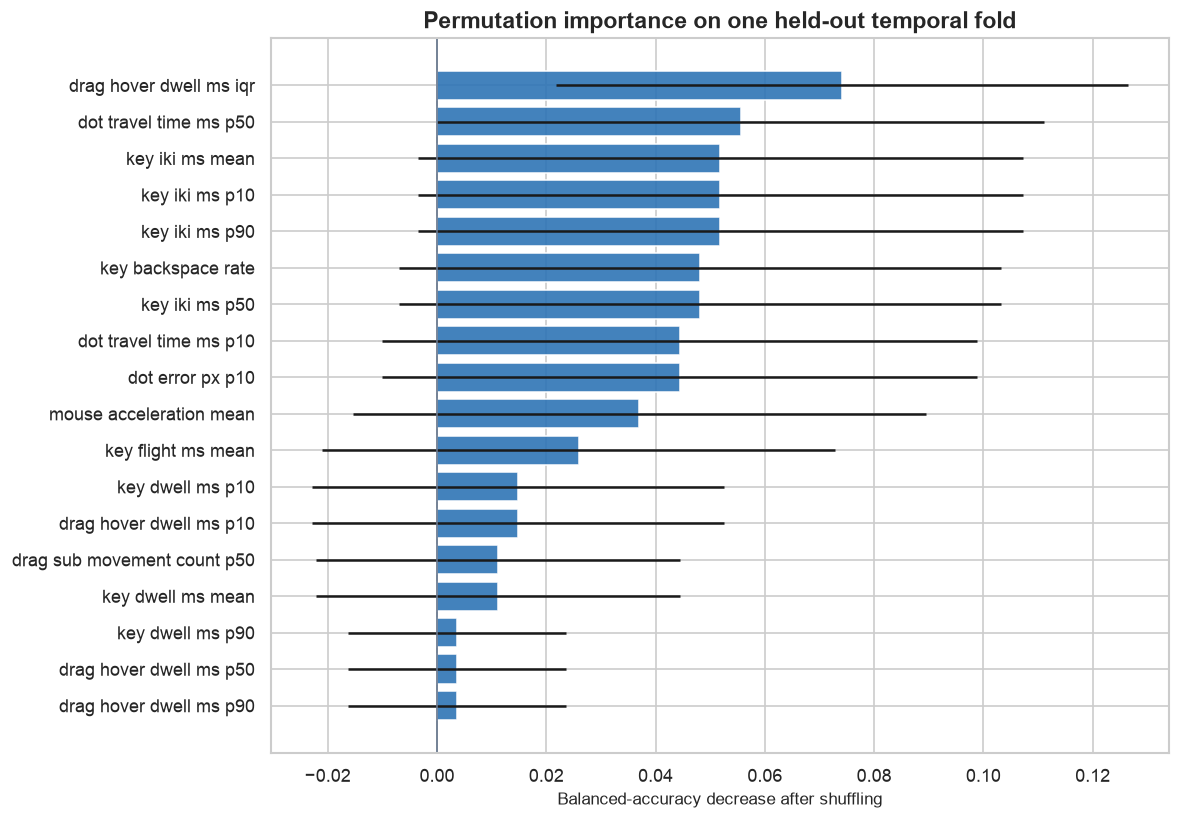

In [18]:
outer = max(np.unique(folds))
train, test = folds != outer, folds == outer
explainer = clone(models['Extra Trees']).fit(X[train], y[train])
importance = permutation_importance(
    explainer, X[test], y[test], scoring='balanced_accuracy', n_repeats=30,
    random_state=SEED, n_jobs=-1,
)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance.importances_mean,
    'uncertainty': importance.importances_std,
}).sort_values('importance', ascending=False).head(18).sort_values('importance')
plt.figure(figsize=(10, 7))
plt.barh(importance_df.feature.str.replace('_', ' '), importance_df.importance,
         xerr=importance_df.uncertainty, color=COLORS[1], alpha=.9)
plt.axvline(0, color='#64748B', lw=1)
plt.title('Permutation importance on one held-out temporal fold')
plt.xlabel('Balanced-accuracy decrease after shuffling')
plt.tight_layout(); plt.show()

## 10. Candidate similarity and PCA map

Similarity is computed between robust-scaled session centroids. It is a relative geometric diagnostic—not a
calibrated probability of identity. PCA is shown only to visualize dominant variance directions.

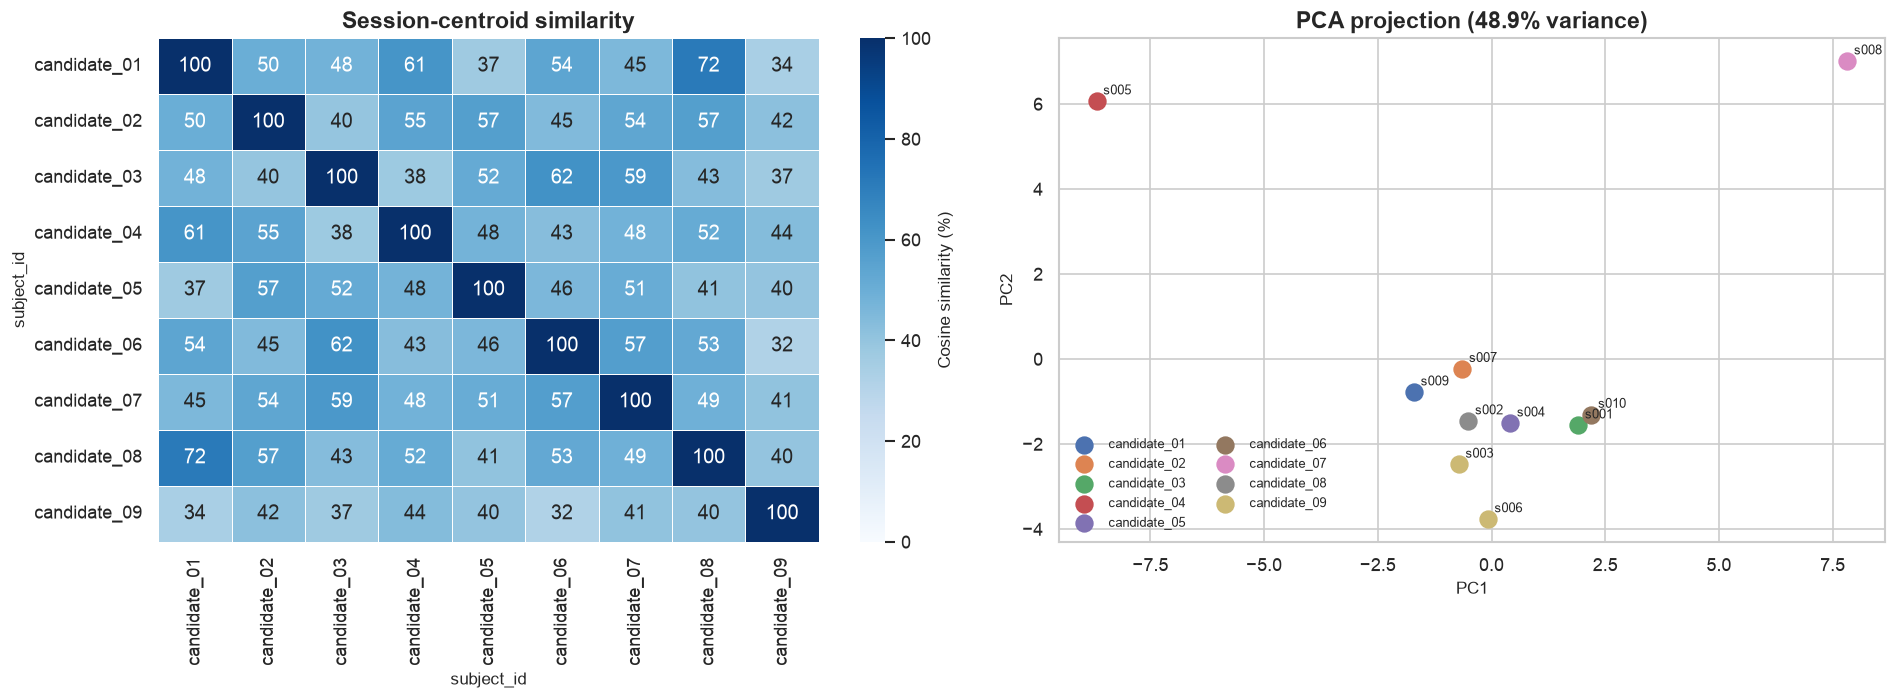

In [19]:
session_feature_names = [c for c in sf.columns if c not in ['session_id', 'subject_id']]
session_matrix = SimpleImputer(strategy='median').fit_transform(sf[session_feature_names])
session_scaled = RobustScaler(quantile_range=(10, 90)).fit_transform(session_matrix)
centroids = pd.DataFrame(session_scaled, index=sf.subject_id).groupby(level=0).mean()
normalized = centroids.to_numpy() / np.maximum(np.linalg.norm(centroids, axis=1, keepdims=True), 1e-9)
similarity = pd.DataFrame((normalized @ normalized.T + 1) * 50, index=centroids.index, columns=centroids.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(similarity, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=100,
            linewidths=.5, cbar_kws={'label': 'Cosine similarity (%)'}, ax=axes[0])
axes[0].set_title('Session-centroid similarity')
pca = PCA(n_components=2, random_state=SEED)
points = pca.fit_transform(session_scaled)
for label in classes:
    mask = sf.subject_id.to_numpy() == label
    axes[1].scatter(points[mask, 0], points[mask, 1], s=100, label=label)
    for x0, y0, sid in zip(points[mask, 0], points[mask, 1], sf.loc[mask, 'session_id']):
        axes[1].annotate(sid.replace('session_', 's'), (x0, y0), xytext=(4, 4), textcoords='offset points', fontsize=8)
axes[1].set_title(f'PCA projection ({pca.explained_variance_ratio_.sum():.1%} variance)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

## 11. Closed-set certainty under open-set stress

A 1:N system must allow *none of the above*. For every temporal fold, we remove one candidate from enrollment,
train on the remaining roster, and compare maximum decision scores for known probes versus probes from the held-out
candidate. This is a small open-set simulation, not a production spoof or zero-effort-impostor study.

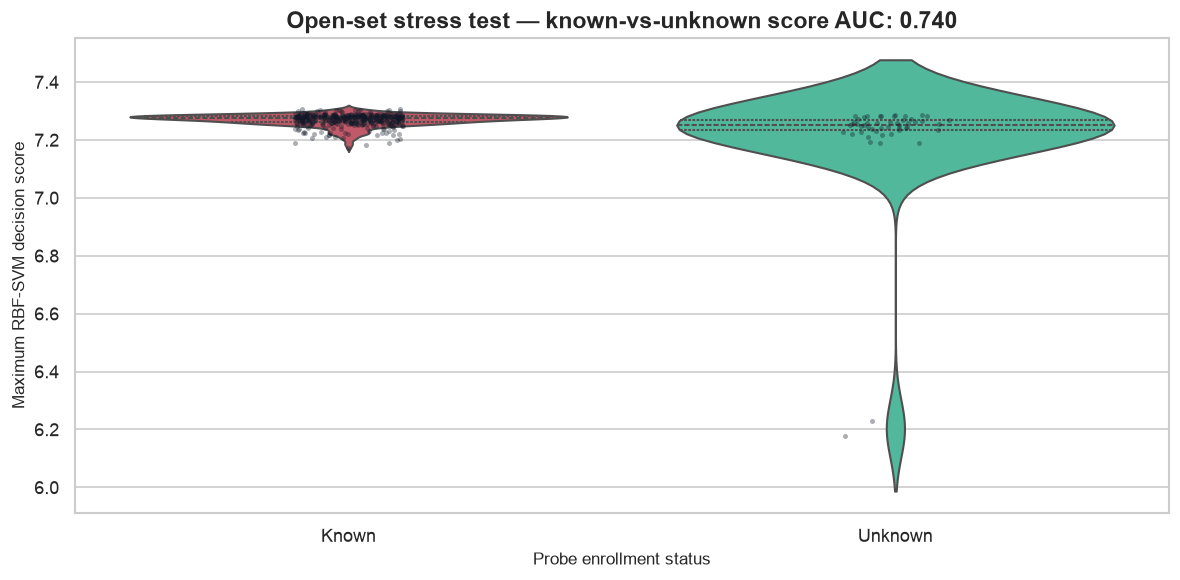

         count   mean    std    min    max
probe                                     
Known      400  7.270  0.021  7.173  7.307
Unknown     50  7.209  0.209  6.178  7.286


In [20]:
open_rows = []
open_model = svm_pipeline(modal_C, modal_gamma)
for unknown in classes:
    for fold in sorted(np.unique(folds)):
        train = (folds != fold) & (y != unknown)
        test = folds == fold
        model = clone(open_model).fit(X[train], y[train])
        raw = np.asarray(model.decision_function(X[test]))
        if raw.ndim == 1:
            raw = np.column_stack([-raw, raw])
        max_score = raw.max(axis=1)
        for label, score in zip(y[test], max_score):
            open_rows.append({'held_out_candidate': unknown, 'probe': 'Unknown' if label == unknown else 'Known', 'max_score': score})
open_df = pd.DataFrame(open_rows)
open_auc = roc_auc_score((open_df.probe == 'Known').astype(int), open_df.max_score)
plt.figure(figsize=(10, 5))
sns.violinplot(data=open_df, x='probe', y='max_score', palette=[COLORS[4], COLORS[2]], inner='quartile')
sns.stripplot(data=open_df, x='probe', y='max_score', color='#111827', alpha=.35, size=3)
plt.title(f'Open-set stress test — known-vs-unknown score AUC: {open_auc:.3f}')
plt.xlabel('Probe enrollment status'); plt.ylabel('Maximum RBF-SVM decision score')
plt.tight_layout(); plt.show()
print(open_df.groupby('probe').max_score.agg(['count', 'mean', 'std', 'min', 'max']).round(3))

## 12. Deep learning: BiLSTM + TCN + engineered-feature fusion

The neural model uses three branches:

- a bidirectional LSTM over keyboard timing/category sequences;
- a temporal convolutional network (TCN) over passive mouse deltas, speed, turn, and time gap;
- a compact MLP over engineered window features.

A single final temporal window is held out. The scaler and imputer are fitted on training windows only. Early
stopping selects the checkpoint with the best held-out macro-F1. Because this is one small development split, the
neural result is evidence that the training path works—not evidence that deep learning is superior.

In [21]:
def pad_or_sample(sequence, length, width):
    sequence = np.nan_to_num(
        np.asarray(sequence, dtype=np.float32), nan=0.0, posinf=5.0, neginf=-5.0
    )
    if len(sequence) == 0:
        return np.zeros((length, width), dtype=np.float32)
    if len(sequence) > length:
        sequence = sequence[np.linspace(0, len(sequence) - 1, length).astype(int)]
    out = np.zeros((length, width), dtype=np.float32)
    out[:len(sequence)] = sequence
    return out

key_events = data['key_events']
mouse_events = data['mouse_passive']
def frame_chunks(frame, count=5):
    boundaries = np.linspace(0, len(frame), count + 1).round().astype(int)
    return [frame.iloc[boundaries[i]:boundaries[i + 1]].copy() for i in range(count)]

key_sequences, mouse_sequences = [], []
for row in wf.itertuples(index=False):
    key = key_events[key_events.session_id == row.session_id].sort_values('press_time_ms')
    mouse = mouse_events[mouse_events.session_id == row.session_id].sort_values('time_ms')
    key_chunks = frame_chunks(key); mouse_chunks = frame_chunks(mouse)
    key = key_chunks[row.window_index - 1].copy(); mouse = mouse_chunks[row.window_index - 1].copy()

    if len(key):
        press = key.press_time_ms.to_numpy(float); release = key.release_time_ms.to_numpy(float)
        dwell = np.nan_to_num(release - press, nan=0) / 250
        iki = np.r_[0, np.diff(press)] / 500
        flight = np.r_[0, press[1:] - release[:-1]] / 500
        key_seq = np.column_stack([
            dwell, np.clip(iki, -3, 3), np.clip(flight, -3, 3),
            key.shift_held.astype(float), (key.key_category == 'space').astype(float),
            (key.key_category == 'special').astype(float),
        ])
    else:
        key_seq = np.empty((0, 6))

    if len(mouse):
        dx = mouse.dx.to_numpy(float); dy = mouse.dy.to_numpy(float)
        dt = np.r_[16, np.maximum(np.diff(mouse.time_ms.to_numpy(float)), 1)]
        speed = np.hypot(dx, dy) / (dt / 1000)
        angle = np.unwrap(np.arctan2(dy, dx)); turn = np.r_[0, np.abs(np.diff(angle))]
        mouse_seq = np.column_stack([
            np.clip(dx / 100, -5, 5), np.clip(dy / 100, -5, 5),
            np.clip(speed / 2000, 0, 5), np.clip(turn / np.pi, 0, 2),
            np.clip(dt / 100, 0, 5),
        ])
    else:
        mouse_seq = np.empty((0, 5))
    key_sequences.append(pad_or_sample(key_seq, 160, 6))
    mouse_sequences.append(pad_or_sample(mouse_seq, 256, 5))

key_sequences = np.asarray(key_sequences, dtype=np.float32)
mouse_sequences = np.asarray(mouse_sequences, dtype=np.float32)
print('Keyboard tensor:', key_sequences.shape, '| Mouse tensor:', mouse_sequences.shape)

Keyboard tensor: (50, 160, 6) | Mouse tensor: (50, 256, 5)


In [22]:
class FusionNet(nn.Module):
    def __init__(self, feature_dim, n_classes):
        super().__init__()
        self.key_lstm = nn.LSTM(6, 20, num_layers=2, batch_first=True,
                                bidirectional=True, dropout=.15)
        self.mouse_tcn = nn.Sequential(
            nn.Conv1d(5, 24, 7, padding=3), nn.GELU(), nn.BatchNorm1d(24),
            nn.Conv1d(24, 32, 5, padding=4, dilation=2), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.features = nn.Sequential(
            nn.LayerNorm(feature_dim), nn.Linear(feature_dim, 96), nn.GELU(), nn.Dropout(.10),
            nn.Linear(96, 48), nn.GELU(),
        )
        self.head = nn.Sequential(
            nn.Linear(40 + 32 + 48, 72), nn.GELU(), nn.Dropout(.15),
            nn.Linear(72, n_classes),
        )
        self.feature_skip = nn.Linear(feature_dim, n_classes)
        self.register_buffer('fusion_scale', torch.tensor(0.0))

    def forward(self, keyboard, mouse, features):
        key_out, _ = self.key_lstm(keyboard)
        key_embedding = key_out.mean(dim=1)
        mouse_embedding = self.mouse_tcn(mouse.transpose(1, 2)).squeeze(-1)
        feature_embedding = self.features(features)
        fused = self.head(torch.cat([key_embedding, mouse_embedding, feature_embedding], dim=1))
        # The engineered branch is deliberately dominant in this tiny-data
        # regime; sequence towers contribute a regularized residual.
        return self.feature_skip(features) + self.fusion_scale * fused

label_encoder = LabelEncoder().fit(y)
neural_y = label_encoder.transform(y)
neural_fold = max(np.unique(folds))
neural_train, neural_valid = folds != neural_fold, folds == neural_fold

imputer = SimpleImputer(strategy='median').fit(X[neural_train])
scaler = StandardScaler().fit(imputer.transform(X[neural_train]))
neural_features = np.clip(scaler.transform(imputer.transform(X)), -8, 8).astype(np.float32)

kt = torch.tensor(key_sequences, device=DEVICE)
mt = torch.tensor(mouse_sequences, device=DEVICE)
ft = torch.tensor(neural_features, device=DEVICE)
yt = torch.tensor(neural_y, dtype=torch.long, device=DEVICE)
train_idx = torch.tensor(np.where(neural_train)[0], device=DEVICE)
valid_idx = torch.tensor(np.where(neural_valid)[0], device=DEVICE)

torch.manual_seed(SEED)
neural_model = FusionNet(len(feature_names), len(classes)).to(DEVICE)
optimizer = torch.optim.AdamW(neural_model.parameters(), lr=3e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=180)
criterion = nn.CrossEntropyLoss(label_smoothing=.03)
history, best_state, best_f1, patience = [], None, -1, 0

for epoch in range(1, 201):
    # Warm up the engineered-feature classifier before allowing the
    # high-variance sequence towers to contribute a small residual.
    if epoch == 16:
        neural_model.fusion_scale.fill_(0.01)
    neural_model.train(); optimizer.zero_grad()
    logits = neural_model(kt[train_idx], mt[train_idx], ft[train_idx])
    loss = criterion(logits, yt[train_idx]); loss.backward()
    nn.utils.clip_grad_norm_(neural_model.parameters(), 2.0)
    optimizer.step(); scheduler.step()

    neural_model.eval()
    with torch.no_grad():
        valid_logits = neural_model(kt[valid_idx], mt[valid_idx], ft[valid_idx])
        valid_pred = valid_logits.argmax(1).cpu().numpy()
    valid_f1 = f1_score(neural_y[neural_valid], valid_pred, average='macro')
    valid_acc = accuracy_score(neural_y[neural_valid], valid_pred)
    history.append({'epoch': epoch, 'loss': float(loss.detach().cpu()),
                    'validation_accuracy': valid_acc, 'validation_macro_f1': valid_f1})
    if epoch >= 16 and valid_f1 > best_f1 + 1e-6:
        best_f1, patience = valid_f1, 0
        best_state = {k: v.detach().cpu().clone() for k, v in neural_model.state_dict().items()}
    else:
        patience += 1
    if epoch >= 60 and patience >= 45:
        break

neural_model.load_state_dict(best_state); neural_model.eval()
with torch.no_grad():
    neural_logits = neural_model(kt[valid_idx], mt[valid_idx], ft[valid_idx]).cpu().numpy()
neural_predictions = neural_logits.argmax(1)
neural_accuracy = accuracy_score(neural_y[neural_valid], neural_predictions)
neural_f1 = f1_score(neural_y[neural_valid], neural_predictions, average='macro')
print(f'Trained {len(history)} epochs | held-out accuracy={neural_accuracy:.1%} | macro-F1={neural_f1:.1%}')

Trained 61 epochs | held-out accuracy=70.0% | macro-F1=55.6%


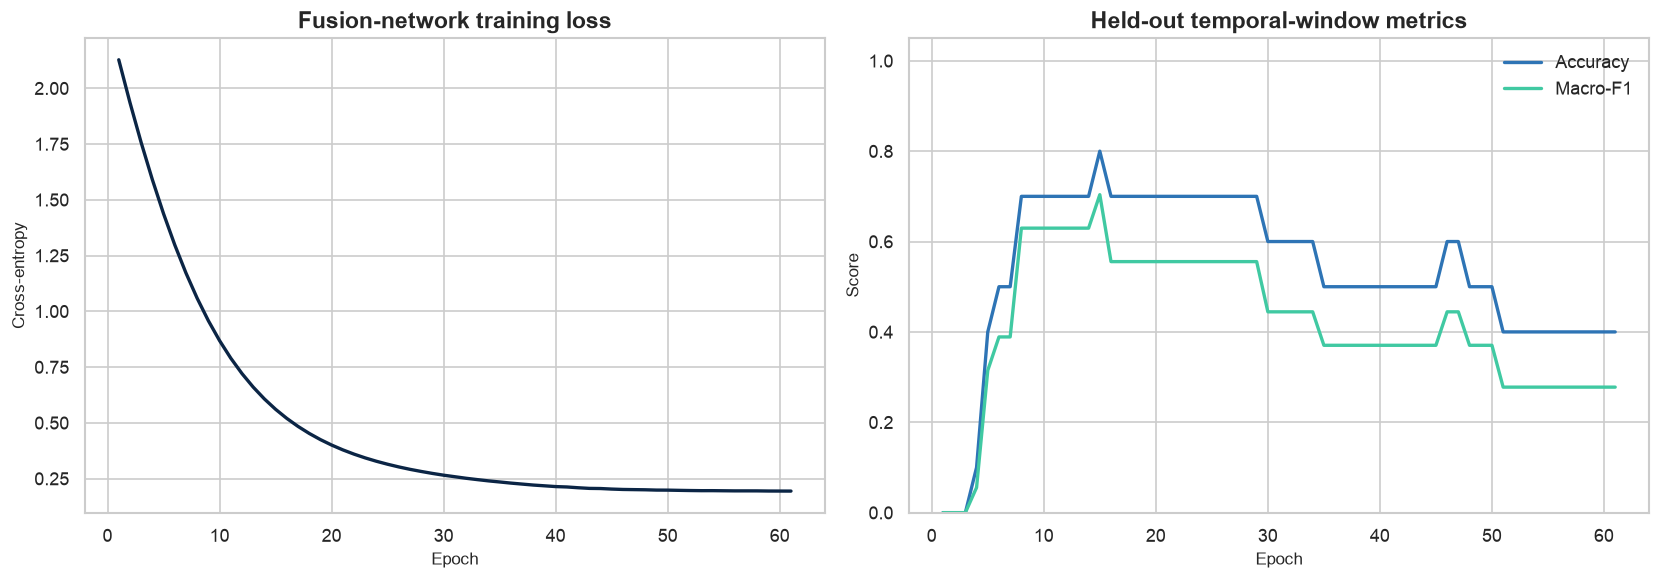

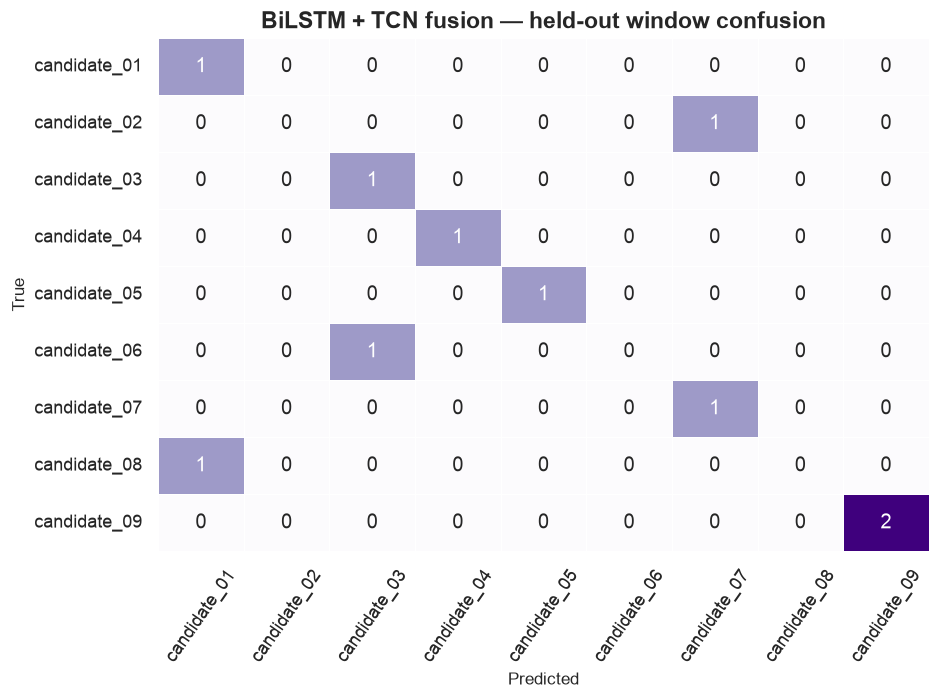

In [23]:
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df.epoch, history_df.loss, color=COLORS[0], lw=2)
axes[0].set(title='Fusion-network training loss', xlabel='Epoch', ylabel='Cross-entropy')
axes[1].plot(history_df.epoch, history_df.validation_accuracy, label='Accuracy', color=COLORS[1], lw=2)
axes[1].plot(history_df.epoch, history_df.validation_macro_f1, label='Macro-F1', color=COLORS[2], lw=2)
axes[1].set(title='Held-out temporal-window metrics', xlabel='Epoch', ylabel='Score', ylim=(0, 1.05))
axes[1].legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
neural_cm = confusion_matrix(neural_y[neural_valid], neural_predictions, labels=np.arange(len(classes)))
sns.heatmap(neural_cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=classes, yticklabels=classes, linewidths=.5)
plt.title('BiLSTM + TCN fusion — held-out window confusion')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.xticks(rotation=55)
plt.tight_layout(); plt.show()

## 13. Certainty calibration diagnostic

Raw multiclass decision values are not probabilities. We convert the nested-SVM scores with a temperature-scaled
softmax and choose temperature on the development out-of-fold predictions. The reliability plot shows whether
top-label confidence tracks observed accuracy. A deployment calibration set must be separate.

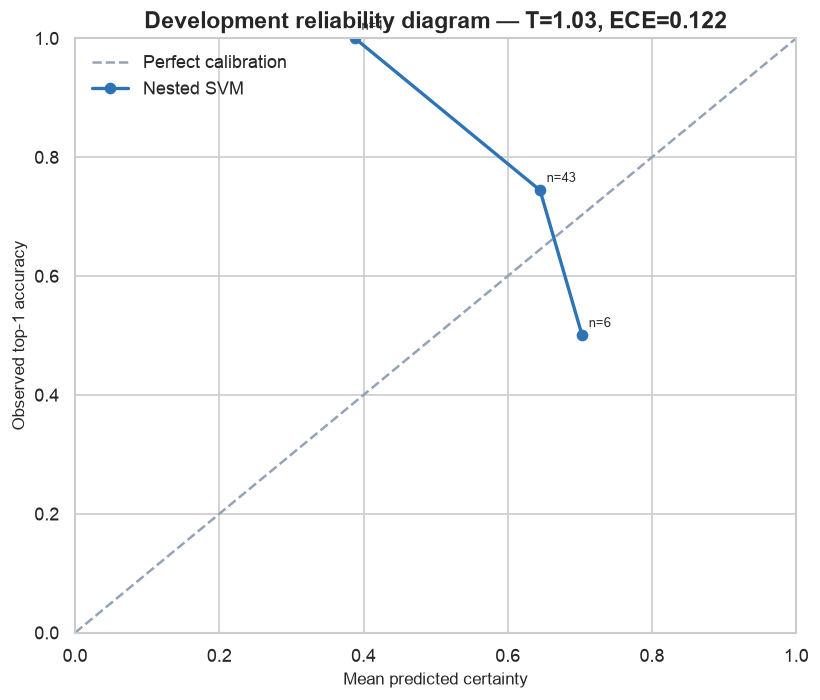

In [24]:
def softmax(scores, temperature=1.0):
    z = scores / temperature
    z = z - z.max(axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / exp.sum(axis=1, keepdims=True)

target_indices = np.array([class_to_index[label] for label in y])
temperatures = np.geomspace(.2, 8, 80)
losses = [log_loss(target_indices, softmax(tuned_scores, t), labels=np.arange(len(classes))) for t in temperatures]
temperature = float(temperatures[np.argmin(losses)])
probabilities = softmax(tuned_scores, temperature)
confidence = probabilities.max(axis=1)
correct = (probabilities.argmax(axis=1) == target_indices).astype(float)
bins = np.linspace(0, 1, 7)
bin_id = np.clip(np.digitize(confidence, bins) - 1, 0, len(bins) - 2)
reliability = pd.DataFrame({'confidence': confidence, 'correct': correct, 'bin': bin_id}).groupby('bin').agg(
    mean_confidence=('confidence', 'mean'), accuracy=('correct', 'mean'), count=('correct', 'size')
).reset_index()
ece = sum(row['count'] / len(y) * abs(row['accuracy'] - row['mean_confidence']) for _, row in reliability.iterrows())

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], '--', color='#94A3B8', label='Perfect calibration')
plt.plot(reliability.mean_confidence, reliability.accuracy, marker='o', lw=2, color=COLORS[1], label='Nested SVM')
for _, row in reliability.iterrows():
    plt.annotate(f"n={int(row['count'])}", (row.mean_confidence, row.accuracy), xytext=(4, 5), textcoords='offset points', fontsize=8)
plt.title(f'Development reliability diagram — T={temperature:.2f}, ECE={ece:.3f}')
plt.xlabel('Mean predicted certainty'); plt.ylabel('Observed top-1 accuracy')
plt.xlim(0, 1); plt.ylim(0, 1); plt.legend(); plt.tight_layout(); plt.show()

## 14. Consolidated results

Classical rows are five-fold out-of-fold estimates. The neural row is a single held-out temporal fold and is kept
separate to avoid implying a directly comparable confidence interval.

In [25]:
final_rows = []
for name, result in classical.items():
    final_rows.append({'Model': name, 'Evaluation': '5-fold temporal',
                       'Balanced accuracy': result['balanced_accuracy'], 'Macro-F1': result['macro_f1'],
                       'Top-3': result['top3_accuracy'], 'Verification AUC': result['verification_auc'], 'EER': result['eer']})
final_rows.append({'Model': 'RBF-SVM (nested tuning)', 'Evaluation': 'Nested 5-fold temporal',
                   'Balanced accuracy': tuned_result['balanced_accuracy'], 'Macro-F1': tuned_result['macro_f1'],
                   'Top-3': tuned_result['top3_accuracy'], 'Verification AUC': tuned_result['verification_auc'], 'EER': tuned_result['eer']})
final_rows.append({'Model': 'BiLSTM + TCN fusion', 'Evaluation': 'Single held-out window',
                   'Balanced accuracy': balanced_accuracy_score(neural_y[neural_valid], neural_predictions),
                   'Macro-F1': neural_f1, 'Top-3': np.nan, 'Verification AUC': np.nan, 'EER': np.nan})
final_table = pd.DataFrame(final_rows).sort_values('Balanced accuracy', ascending=False)
display(final_table.style.format({c: '{:.1%}' for c in ['Balanced accuracy', 'Macro-F1', 'Top-3', 'Verification AUC', 'EER']}, na_rep='—')
        .background_gradient(cmap='YlGn', subset=['Balanced accuracy', 'Macro-F1']).hide(axis='index'))

Model,Evaluation,Balanced accuracy,Macro-F1,Top-3,Verification AUC,EER
Extra Trees,5-fold temporal,95.6%,95.6%,100.0%,99.7%,2.3%
Random Forest,5-fold temporal,93.3%,93.5%,100.0%,99.8%,1.5%
3-NN,5-fold temporal,68.9%,65.2%,86.0%,90.5%,12.6%
RBF-SVM (nested tuning),Nested 5-fold temporal,67.8%,67.3%,92.0%,93.2%,12.1%
BiLSTM + TCN fusion,Single held-out window,66.7%,55.6%,—,—,—
Logistic regression,5-fold temporal,65.6%,64.5%,96.0%,95.3%,9.7%
RBF-SVM (default),5-fold temporal,65.6%,66.1%,86.0%,91.5%,20.1%


## 15. Conclusions and next experiments

**What this notebook establishes**

- The full anonymized pipeline runs end to end from event tables to classical and neural models.
- Keyboard rhythm, passive motion, and goal-directed mouse tasks carry complementary structure.
- Nested SVM tuning prevents the most direct form of hyperparameter-selection optimism.
- Identification, verification, calibration, and open-set rejection expose different failure modes.
- A BiLSTM+TCN fusion model can be trained from the released sequences, but the current cohort is too small to
  justify a neural-over-classical claim.

**Highest-value next data collection**

1. Collect at least five independent sessions per candidate across at least three days.
2. Deliberately vary device, browser, pointer hardware, posture, fatigue, and time of day.
3. Freeze preprocessing and tuning before opening a session-disjoint test set.
4. Add unknown candidates and scripted/replayed-input attacks to the test protocol.
5. Report FAR/FRR with trial counts and confidence intervals at application-specific thresholds.
6. Evaluate fairness and accessibility burden without treating demographic attributes as identity features.

Behavioral biometrics should be a **risk signal or additional factor**, not a standalone authenticator. NIST notes
that biometric comparison is probabilistic and places biometrics within multi-factor authentication controls [1].

## References

1. NIST. *Digital Identity Guidelines: Authentication and Authenticator Management*, SP 800-63B-4 (2025). https://pages.nist.gov/800-63-4/sp800-63b.html
2. ISO/IEC 19795-1:2021. *Biometric performance testing and reporting — Principles and framework*. https://www.iso.org/standard/73515.html
3. ISO/IEC 24745:2022. *Biometric information protection*. https://www.iso.org/standard/75302.html
4. Monrose, F. & Rubin, A. D. “Keystroke dynamics as a biometric for authentication.” *Future Generation Computer Systems* 16(4), 351–359 (2000). https://doi.org/10.1016/S0167-739X(99)00059-X
5. Killourhy, K. S. & Maxion, R. A. “Comparing anomaly-detection algorithms for keystroke dynamics.” DSN (2009). https://doi.org/10.1109/DSN.2009.5270346
6. Shen, C. et al. “User authentication through mouse dynamics.” *IEEE TIFS* 8(1), 16–30 (2013). https://doi.org/10.1109/TIFS.2012.2223677
7. Mondal, S. & Bours, P. “Continuous authentication using a combination of keystroke and mouse biometrics.” *Neurocomputing* 230, 1–22 (2017). https://doi.org/10.1016/j.neucom.2016.11.031
8. Hochreiter, S. & Schmidhuber, J. “Long short-term memory.” *Neural Computation* 9(8), 1735–1780 (1997). https://doi.org/10.1162/neco.1997.9.8.1735
9. Bai, S., Kolter, J. Z. & Koltun, V. “An empirical evaluation of generic convolutional and recurrent networks for sequence modeling.” arXiv:1803.01271 (2018). https://arxiv.org/abs/1803.01271
10. Guo, C. et al. “On calibration of modern neural networks.” ICML/PMLR 70 (2017). https://proceedings.mlr.press/v70/guo17a.html

---
**Responsible-use reminder:** behavioral traces remain biometric-adjacent even after pseudonymization. Do not
attempt re-identification or use this small development dataset for consequential decisions.